In [ ]:
!pip install -U bitsandbytes>=0.46.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Install necessary libraries (Run this in your first Colab cell)
!pip install -q transformers datasets torch Pillow

# 2. Main Architecture Script
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel
import torch

# --- Step 1: Load the Chest X-Ray Dataset ---
print("Loading Indiana University Chest X-Ray Dataset...")
full_dataset = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")

# Step 1: Split off 20% for the combined Validation/Test pool (Leaving 80% for Train)
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_split = train_test_split['train']
test_val_pool = train_test_split['test']

# Step 2: Split the 20% pool strictly in half to create 10% Validation and 10% Test
val_test_split = test_val_pool.train_test_split(test_size=0.5, seed=42)
val_split = val_test_split['train']
test_split = val_test_split['test']

print(f"Training Pool:   {len(train_split)} images")
print(f"Validation Pool: {len(val_split)} images")
print(f"Holdout Test Pool: {len(test_split)} images\n")

Loading Indiana University Chest X-Ray Dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

data/train-00000-of-00003-34bea7eff0b2e4(…):   0%|          | 0.00/369M [00:00<?, ?B/s]

data/train-00001-of-00003-e264f8a8545640(…):   0%|          | 0.00/369M [00:00<?, ?B/s]

data/train-00002-of-00003-b727c3f3dd3884(…):   0%|          | 0.00/370M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6060 [00:00<?, ? examples/s]

Training Pool:   4848 images
Validation Pool: 606 images
Holdout Test Pool: 606 images



1. Initializing Architecture...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading weights from /content/drive/MyDrive/msc_medical_vlm_weights_final/checkpoint-epoch-6...
2. Booting Target-Free XAI Engine...
3. Running Target-Free Evaluation on Test Set...

Processing Index 110...
  -> Generating VLM (Ours)...
  -> Generating Grad-CAM (Holistic)...
  [Model Generated]: 'the lungs are clear there is no pleural effusion or pneumothorax the heart and mediastinum are normal the skeletal structures are normal'
  -> Generating HiResCAM (Holistic)...
  [Model Generated]: 'the lungs are clear there is no pleural effusion or pneumothorax the heart and mediastinum are normal the skeletal structures are normal'
  -> Generating Score-CAM (Holistic)...
  [Model Generated]: 'the lungs are clear there is no pleural effusion or pneumothorax the heart and mediastinum are normal the skeletal structures are normal'

Processing Index 350...
  -> Generating VLM (Ours)...
  -> Generating Grad-CAM (Holistic)...
  [Model Generated]: 'the lungs are clear there is no pleural effusion 

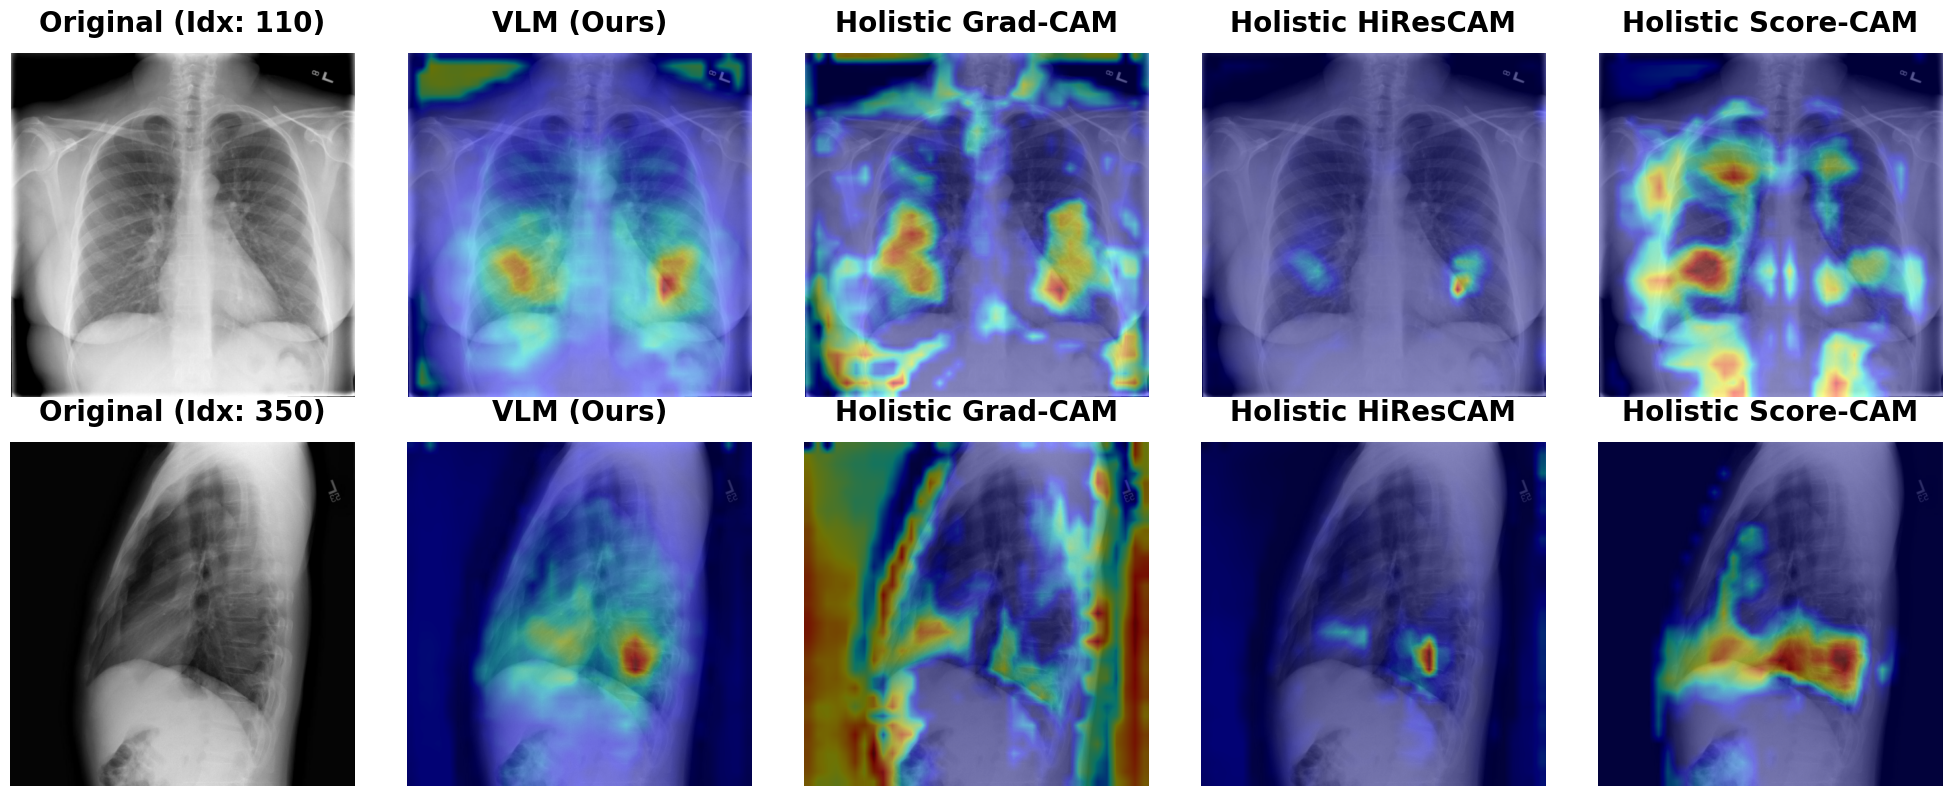


--- ✅ Full Holistic XAI Evaluation Complete ---


In [ ]:
import os
import re
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# ==============================================================================
# PART 1: ARCHITECTURE & WEIGHT LOADING
# ==============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("1. Initializing Architecture...")

vision_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
vision_encoder = AutoModel.from_pretrained("microsoft/rad-dino").to(device)
vision_encoder.eval()

llm_id = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_id)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)
base_llm = AutoModelForCausalLM.from_pretrained(llm_id, quantization_config=bnb_config, device_map={"": 0})

class QFormerProjector(nn.Module):
    def __init__(self, num_queries=64, vision_dim=768, llm_dim=3584):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, vision_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim=vision_dim, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(vision_dim)
        self.ffn = nn.Sequential(nn.Linear(vision_dim, vision_dim * 4), nn.GELU(), nn.Linear(vision_dim * 4, vision_dim))
        self.norm2 = nn.LayerNorm(vision_dim)
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.llm_norm = nn.LayerNorm(llm_dim)

    def forward(self, patch_embeddings, return_attention=False):
        spatial_patches = patch_embeddings[:, 1:, :]
        batch_size = spatial_patches.shape[0]
        queries = self.query_tokens.expand(batch_size, -1, -1)
        attn_output, attn_weights = self.cross_attn(
            query=queries, key=spatial_patches, value=spatial_patches,
            need_weights=True, average_attn_weights=True
        )
        x = self.norm1(queries + attn_output)
        x = self.norm2(x + self.ffn(x))
        out = self.llm_norm(self.proj(x))
        if return_attention: return out, attn_weights
        return out

projector = QFormerProjector(num_queries=64, vision_dim=768, llm_dim=base_llm.config.hidden_size).to(device)

LOAD_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final/checkpoint-epoch-6"
print(f"Loading weights from {LOAD_DIR}...")
projector.load_state_dict(torch.load(os.path.join(LOAD_DIR, "vision_projector.pth"), map_location=device))
efficient_llm = PeftModel.from_pretrained(base_llm, os.path.join(LOAD_DIR, "qwen_lora_adapters"))

projector.eval()
efficient_llm.eval()

# ==============================================================================
# PART 2: TARGET-FREE XAI ENGINE (WITH RANDOM TRAINING PROMPTS)
# ==============================================================================
print("2. Booting Target-Free XAI Engine...")

def get_random_clinical_prompt():
    """Matches your exact training distribution."""
    instructions = [
        "Analyze this chest radiograph and generate a concise clinical report.",
        "Review this CXR and detail findings for the lungs, heart, and pleura.",
        "Provide a structured diagnostic report for this chest X-ray using standard radiology terminology."
    ]
    return (
        "<|im_start|>system\n"
        "You are an expert radiologist. Write ONLY the diagnostic narrative.<|im_end|>\n"
        f"<|im_start|>user\n{random.choice(instructions)}<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

def generate_report(image, prompt_text):
    pv = vision_processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            patch_emb = vision_encoder(pv).last_hidden_state.to(torch.float16)
            visual_prompts = projector(patch_emb)
            prompt_ids = tokenizer(prompt_text, return_tensors="pt").input_ids.to(device)
            prompt_embeds = efficient_llm.get_input_embeddings()(prompt_ids)
            inputs_embeds = torch.cat([visual_prompts, prompt_embeds], dim=1)
            outputs = efficient_llm.generate(inputs_embeds=inputs_embeds, max_new_tokens=40, do_sample=False)
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

def get_holistic_gradients_and_activations(image, prompt_text):
    gen_text = generate_report(image, prompt_text)
    print(f"  [Model Generated]: '{gen_text}'")

    pv = vision_processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        dino_out = vision_encoder(pv).last_hidden_state.to(torch.float16)

    spatial_patches = dino_out[:, 1:, :].detach().clone()
    spatial_patches.requires_grad_(True)

    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
        batch_size = spatial_patches.shape[0]
        queries = projector.query_tokens.expand(batch_size, -1, -1)

        attn_output, attn_weights = projector.cross_attn(
            query=queries, key=spatial_patches, value=spatial_patches, need_weights=True, average_attn_weights=True)

        x = projector.norm1(queries + attn_output)
        x = projector.norm2(x + projector.ffn(x))
        visual_prompts = projector.llm_norm(projector.proj(x))

        full_text = prompt_text + gen_text
        full_ids = tokenizer(full_text, return_tensors="pt").input_ids.to(device)
        gen_ids = tokenizer(gen_text, add_special_tokens=False, return_tensors="pt").input_ids.to(device)[0]

        text_embeds = efficient_llm.get_input_embeddings()(full_ids)
        inputs_embeds = torch.cat([visual_prompts, text_embeds], dim=1)

        projector.zero_grad()
        efficient_llm.zero_grad()

        outputs = efficient_llm(inputs_embeds=inputs_embeds[:, :-1, :])
        logits = outputs.logits[0]

        prompt_length = tokenizer(prompt_text, return_tensors="pt").input_ids.shape[1]
        start_idx = 64 + prompt_length - 1

        holistic_score = 0
        for i, token_id in enumerate(gen_ids):
            if start_idx + i < logits.shape[0]:
                holistic_score += logits[start_idx + i, token_id]

    holistic_score.backward()

    return {
        'patches_act': spatial_patches.detach()[0],
        'patches_grad': spatial_patches.grad[0],
        'cross_attn_act': attn_weights.detach()[0],
        'gen_ids': gen_ids,
        'start_idx': start_idx
    }

def format_heatmap(cam_1d, image_size):
    grid_size = int(math.sqrt(cam_1d.shape[0]))
    cam_grid = cam_1d.view(1, 1, grid_size, grid_size)
    upscaled = F.interpolate(cam_grid, size=image_size, mode='bilinear', align_corners=False)
    heatmap = upscaled.squeeze().cpu().numpy()
    if heatmap.max() > 0:
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap

# ==============================================================================
# PART 3: THE TARGET-FREE XAI METHODS
# ==============================================================================

def vlm_cross_attention(image):
    pv = vision_processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            patch_emb = vision_encoder(pv).last_hidden_state.to(torch.float16)
            _, attn_weights = projector(patch_emb, return_attention=True)
    cam = attn_weights.squeeze(0).mean(dim=0)
    return format_heatmap(cam, image.size[::-1]) # BUG 2 FIX: transposed size

def vlm_gradcam(image, prompt_text):
    data = get_holistic_gradients_and_activations(image, prompt_text)
    weights = data['patches_grad'].mean(dim=0)
    cam = F.relu((data['patches_act'] * weights).sum(dim=-1))
    return format_heatmap(cam, image.size[::-1]) # BUG 2 FIX: transposed size

def vlm_hirescam(image, prompt_text):
    data = get_holistic_gradients_and_activations(image, prompt_text)
    cam = F.relu((data['patches_grad'] * data['patches_act']).sum(dim=-1))
    return format_heatmap(cam, image.size[::-1]) # BUG 2 FIX: transposed size

def vlm_scorecam(image, prompt_text, batch_size=8):
    baseline_data = get_holistic_gradients_and_activations(image, prompt_text)
    gen_ids = baseline_data['gen_ids']
    start_idx = baseline_data['start_idx']

    pv = vision_processor(images=image, return_tensors='pt').pixel_values.to(device)
    H, W = pv.shape[2], pv.shape[3]

    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            patch_emb = vision_encoder(pv).last_hidden_state.to(torch.float16)


    spatial_patches = patch_emb[0, 1:, :] # shape: [196, 768]
    num_channels = spatial_patches.shape[-1] # 768
    grid_size = int(math.sqrt(spatial_patches.shape[0])) # 14

    # Reshape the 768 spatial feature maps to [768, 1, 14, 14] to act as our masks
    masks_grid = spatial_patches.t().view(num_channels, 1, grid_size, grid_size)

    # Upsample masks to input image resolution
    masks_upscaled = F.interpolate(masks_grid, size=(H, W), mode='bilinear', align_corners=False)

    # Normalize each mask to [0, 1] range individually
    masks_min = masks_upscaled.view(num_channels, -1).min(dim=1)[0].view(num_channels, 1, 1, 1)
    masks_max = masks_upscaled.view(num_channels, -1).max(dim=1)[0].view(num_channels, 1, 1, 1)
    masks = (masks_upscaled - masks_min) / (masks_max - masks_min + 1e-8)

    weights = torch.zeros(num_channels, device=device)

    gen_text = tokenizer.decode(gen_ids)
    full_text = prompt_text + gen_text
    full_ids = tokenizer(full_text, return_tensors="pt").input_ids.to(device)
    text_embeds = efficient_llm.get_input_embeddings()(full_ids)


    baseline_pv = torch.zeros_like(pv)
    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            b_patch_emb = vision_encoder(baseline_pv).last_hidden_state.to(torch.float16)
            b_visual_prompts = projector(b_patch_emb)
            b_inputs = torch.cat([b_visual_prompts, text_embeds], dim=1)
            b_outputs = efficient_llm(inputs_embeds=b_inputs[:, :-1, :])
            b_logits = b_outputs.logits[0]

            baseline_score = 0
            for i, token_id in enumerate(gen_ids):
                if start_idx + i < b_logits.shape[0]:
                    baseline_score += b_logits[start_idx + i, token_id].item()


    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            for s in range(0, num_channels, batch_size):
                e = min(s + batch_size, num_channels)
                masked_pv = pv * masks[s:e]
                m_patch_emb = vision_encoder(masked_pv).last_hidden_state.to(torch.float16)
                m_visual_prompts = projector(m_patch_emb)

                batch_text_embeds = text_embeds.expand(m_visual_prompts.shape[0], -1, -1)
                m_inputs = torch.cat([m_visual_prompts, batch_text_embeds], dim=1)
                m_outputs = efficient_llm(inputs_embeds=m_inputs[:, :-1, :])
                m_logits = m_outputs.logits

                for b_idx in range(m_logits.shape[0]):
                    m_holistic_score = 0
                    for i, token_id in enumerate(gen_ids):
                        if start_idx + i < m_logits.shape[1]:
                            m_holistic_score += m_logits[b_idx, start_idx + i, token_id].item()


                    weights[s + b_idx] = m_holistic_score - baseline_score


    weights = weights.view(num_channels, 1, 1)


    scorecam = (weights.cpu() * masks_grid.squeeze(1).cpu()).sum(dim=0)
    scorecam = F.relu(scorecam) # Apply ReLU to only keep positive causal contributions


    return format_heatmap(scorecam.flatten(), image.size[::-1])

# ==============================================================================
# PART 4: TARGET-FREE EXECUTION LOOP (GRID PLOTTING)
# ==============================================================================
print("3. Running Target-Free Evaluation on Test Set...")

test_indices = [ 110, 350]

num_rows = len(test_indices)
num_cols = 5 # 1 Original + 4 XAI Methods

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows), squeeze=False)

for row_idx, idx in enumerate(test_indices):
    print(f"\nProcessing Index {idx}...")
    item = test_split[idx]
    image = item['image'].convert('RGB')

    # 1. Generate the exact random prompt to use for all maps on this image
    current_prompt = get_random_clinical_prompt()

    # 2. Generate Maps
    print("  -> Generating VLM (Ours)...")
    hm_ours = vlm_cross_attention(image)

    print("  -> Generating Grad-CAM (Holistic)...")
    hm_gradcam = vlm_gradcam(image, current_prompt)

    print("  -> Generating HiResCAM (Holistic)...")
    hm_hirescam = vlm_hirescam(image, current_prompt)

    print("  -> Generating Score-CAM (Holistic)...")
    hm_scorecam = vlm_scorecam(image, current_prompt)

    # 3. Plotting into the grid
    row_axes = axes[row_idx] # Get the specific row of axes

    row_axes[0].imshow(image, cmap='gray')
    row_axes[0].set_title(f"Original (Idx: {idx})",
                          fontsize=20,
                          fontweight='black', # 'black' is the heaviest bold weight in matplotlib
                          color='black',
                          pad=15)
    row_axes[0].axis('off')

    maps = [
        ("VLM (Ours)", hm_ours),
        ("Holistic Grad-CAM", hm_gradcam),
        ("Holistic HiResCAM", hm_hirescam),
        ("Holistic Score-CAM", hm_scorecam)
    ]

    for col_idx, (title, heatmap) in enumerate(maps):
        ax = row_axes[col_idx + 1]
        ax.imshow(image, cmap='gray')
        im = ax.imshow(heatmap, cmap='jet', alpha=0.45)

        # --- UPDATED: Larger, bolder, darker text for the XAI Methods ---
        ax.set_title(title,
                     fontsize=20,
                     fontweight='black',
                     color='black',
                     pad=15)
        ax.axis('off')

    torch.cuda.empty_cache()

plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/msc_medical_vlm_weights_final/vlm_xai_comparison_all_indices.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n--- ✅ Full Holistic XAI Evaluation Complete ---")


ARCHITECTURAL COST MODEL (pass counts — independent of hardware)
                    forward_passes backward_passes                                                                                                                                                 description
Method                                                                                                                                                                                                        
VLM Cross-Attention              1               0                                                                   Single forward pass through rad-dino + Q-Former. No gradients, no re-generation per mask.
Holistic Grad-CAM                1               1                                                           One generate() call + one forward/backward pass through the full pipeline for the holistic score.
Holistic HiResCAM                1               1  Identical cost profile to Grad-CAM — both reuse get_ho

Efficiency report:   0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1115: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'


/tmp/ipykernel_1849/3941168554.py:243: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['deletion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))
/tmp/ipykernel_1849/3941168554.py:264: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['insertion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))


  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no p

...

  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there are  opacities in the right midlung and left lower lung base which may represent atelectasis or scarring'
  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there are  opacities in the right midlung and left lower lung base which may represent atelectasis or scarring'
  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there are  opacities in the right midlung and left lower lung base which may represent atelectasis or scarring'
  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there are  opacities in the right midlung and left lower lung base which may represent atelectasis or scarring'
  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there are  opacities in the right midlung and left lower lung base which may represent atelectasis or scarring'
  [Model Generated]: 'the hear

Efficiency report:  80%|████████  | 4/5 [17:02<04:17, 257.22s/it]

  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the 

Efficiency report: 100%|██████████| 5/5 [21:12<00:00, 254.57s/it]



EFFICIENCY REPORT — SPEED + FAITHFULNESS  (averaged over 5 images)
             method  mean_time_s  std_time_s  peak_mem_mb  forward_passes  backward_passes  deletion_auc  deletion_auc_std  insertion_auc  insertion_auc_std  faithfulness_gap
  Holistic Grad-CAM       6.2275      0.7214    6769.2654               1                1        0.9874            0.0111         0.9927             0.0078            0.0053
  Holistic HiResCAM       6.2358      0.7115    6771.4217               1                1        0.9860            0.0100         0.9911             0.0075            0.0050
 Holistic Score-CAM      98.3731      2.9440    7652.1793              65                1        0.9940            0.0091         0.9904             0.0090           -0.0036
VLM Cross-Attention       0.0344      0.0020    5339.7147               1                0        0.9923            0.0082         0.9914             0.0092           -0.0009

Reading the table:
  mean_time_s      : wall-clock secon

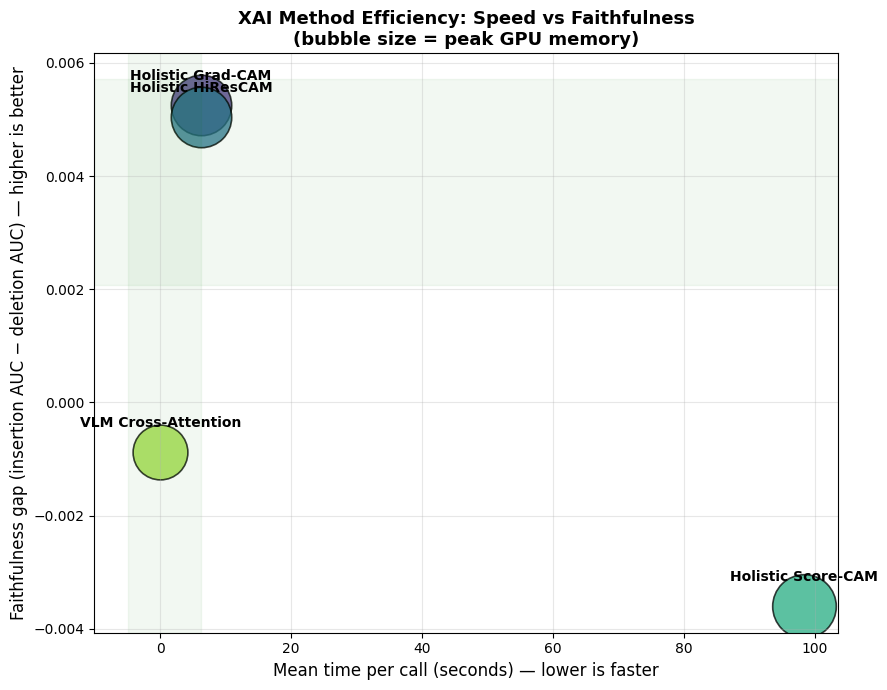

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1115: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'


/tmp/ipykernel_1849/3941168554.py:243: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['deletion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))
/tmp/ipykernel_1849/3941168554.py:264: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['insertion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))


Saved: /content/drive/MyDrive/msc_medical_vlm_weights_final/xai_deletion_insertion_curves.png


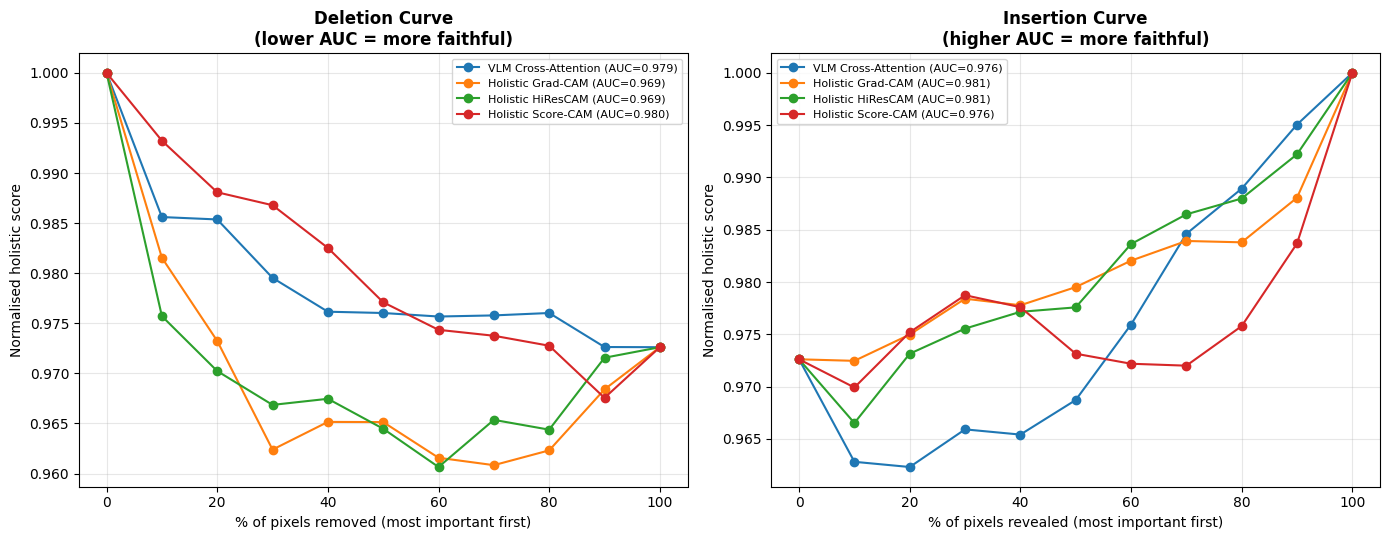

In [ ]:
import time
import math
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm




# -----------------------------------------------------------------------------
# AXIS 1 — COMPUTATIONAL COST PROFILING
# -----------------------------------------------------------------------------
def profile_method(fn, *args, n_repeats=3, **kwargs):
    """
    Times a single XAI method call and measures peak GPU memory.

    Parameters
    ----------
    fn         : the XAI function to profile (e.g. vlm_gradcam)
    *args      : positional args to pass to fn (e.g. image, prompt_text)
    n_repeats  : number of repeats to average over (reduces noise from
                 CUDA warm-up / caching effects)

    Returns
    -------
    dict with keys: mean_time_s, std_time_s, peak_mem_mb, heatmap (last run)
    """
    times = []
    heatmap = None

    for i in range(n_repeats):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

        t0 = time.perf_counter()
        heatmap = fn(*args, **kwargs)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

        times.append(t1 - t0)

    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    return {
        'mean_time_s': float(np.mean(times)),
        'std_time_s':  float(np.std(times)),
        'peak_mem_mb': float(peak_mem_mb),
        'heatmap':     heatmap,
    }


# Forward/backward pass counts are architectural facts, not measured at
# runtime — they depend on each method's algorithm, not the specific image.
# Score-CAM batches 64 query masks in groups of `batch_size` (default 8),
# so its pass count below assumes the default from vlm_scorecam().
METHOD_COST_MODEL = {
    'VLM Cross-Attention': {
        'forward_passes':  1,
        'backward_passes': 0,
        'description': 'Single forward pass through rad-dino + Q-Former. '
                        'No gradients, no re-generation per mask.',
    },
    'Holistic Grad-CAM': {
        'forward_passes':  1,
        'backward_passes': 1,
        'description': 'One generate() call + one forward/backward pass '
                        'through the full pipeline for the holistic score.',
    },
    'Holistic HiResCAM': {
        'forward_passes':  1,
        'backward_passes': 1,
        'description': 'Identical cost profile to Grad-CAM — both reuse '
                        'get_holistic_gradients_and_activations(); they differ '
                        'only in how gradients are pooled, not in pass count.',
    },
    'Holistic Score-CAM': {
        'forward_passes':  1 + 64,  # 1 holistic pass (for gen_ids) + 64 masked passes
        'backward_passes': 1,        # the internal holistic pass still backprops once
        'description': 'One holistic pass to establish gen_ids/start_idx, '
                        'plus 64 additional forward passes (one per Q-Former '
                        'query mask) batched in groups of 8 by default.',
    },
}


def print_cost_model():
    print("\n" + "="*78)
    print("ARCHITECTURAL COST MODEL (pass counts — independent of hardware)")
    print("="*78)
    df = pd.DataFrame(METHOD_COST_MODEL).T
    df.index.name = 'Method'
    print(df[['forward_passes', 'backward_passes', 'description']].to_string())
    print("="*78)




def _holistic_score_for_image(image, prompt_text, gen_ids, start_idx,
                               vision_processor, vision_encoder, projector,
                               efficient_llm, tokenizer, device):
    """
    Forward-passes `image` through the full pipeline and returns the
    holistic score (sum of logits for the tokens in gen_ids), WITHOUT
    re-generating text. Used to probe the model's response to perturbed
    (deleted/inserted) versions of the original image.
    """
    pv = vision_processor(images=image, return_tensors='pt').pixel_values.to(device)

    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            patch_emb = vision_encoder(pv).last_hidden_state.to(torch.float16)
            visual_prompts = projector(patch_emb)

            full_text = prompt_text + tokenizer.decode(gen_ids)
            full_ids  = tokenizer(full_text, return_tensors="pt").input_ids.to(device)
            text_embeds = efficient_llm.get_input_embeddings()(full_ids)

            inputs_embeds = torch.cat([visual_prompts, text_embeds], dim=1)
            outputs = efficient_llm(inputs_embeds=inputs_embeds[:, :-1, :])
            logits  = outputs.logits[0]

            score = 0.0
            for i, token_id in enumerate(gen_ids):
                if start_idx + i < logits.shape[0]:
                    score += logits[start_idx + i, token_id].item()
    return score


def deletion_insertion_curves(image, heatmap, prompt_text, gen_ids, start_idx,
                               vision_processor, vision_encoder, projector,
                               efficient_llm, tokenizer, device,
                               n_steps=10, mode='both'):
    """
    Computes Deletion and/or Insertion curves for a single heatmap.

    Parameters
    ----------
    image      : PIL.Image  original input
    heatmap    : np.ndarray [H, W] in [0,1], higher = more important
    n_steps    : number of perturbation steps (10 = remove/reveal in 10% chunks)
    mode       : 'deletion' | 'insertion' | 'both'

    Returns
    -------
    dict with 'deletion_scores', 'insertion_scores' (lists of holistic scores
    at each step) and 'deletion_auc', 'insertion_auc'.
    AUC is computed via trapezoidal rule over normalised step fractions [0,1].
    """
    img_arr = np.array(image.convert('RGB')).astype(np.float32)
    H, W, _ = img_arr.shape

    # Resize heatmap to image resolution and flatten with importance ranking
    hm_t = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
    hm_resized = F.interpolate(hm_t, size=(H, W), mode='bilinear', align_corners=False)
    hm_resized = hm_resized.squeeze().numpy()

    flat_importance = hm_resized.flatten()
    order = np.argsort(-flat_importance)   # descending: most important pixels first
    total_pixels = order.shape[0]
    chunk_size = total_pixels // n_steps

    grey_value = float(img_arr.mean())   # neutral baseline grey

    results = {}

    score_kwargs = dict(
        vision_processor=vision_processor, vision_encoder=vision_encoder,
        projector=projector, efficient_llm=efficient_llm,
        tokenizer=tokenizer, device=device,
    )

    if mode in ('deletion', 'both'):
        deletion_scores = []
        working = img_arr.copy()
        flat_working = working.reshape(-1, 3)
        for step in range(n_steps + 1):
            n_remove = step * chunk_size
            if n_remove > 0:
                idx_to_remove = order[:n_remove]
                flat_working[idx_to_remove] = grey_value
            perturbed_img = Image.fromarray(
                flat_working.reshape(H, W, 3).clip(0, 255).astype(np.uint8)
            )
            s = _holistic_score_for_image(perturbed_img, prompt_text, gen_ids,
                                           start_idx, **score_kwargs)
            deletion_scores.append(s)
        results['deletion_scores'] = deletion_scores
        # Normalise scores relative to the step-0 (unperturbed) score so AUC
        # is comparable across images/methods with different score scales
        s0 = deletion_scores[0]
        norm = [s / s0 if s0 != 0 else 0.0 for s in deletion_scores]
        results['deletion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))

    if mode in ('insertion', 'both'):
        insertion_scores = []
        working = np.full_like(img_arr, grey_value)
        flat_working = working.reshape(-1, 3)
        flat_original = img_arr.reshape(-1, 3)
        for step in range(n_steps + 1):
            n_reveal = step * chunk_size
            if n_reveal > 0:
                idx_to_reveal = order[:n_reveal]
                flat_working[idx_to_reveal] = flat_original[idx_to_reveal]
            perturbed_img = Image.fromarray(
                flat_working.reshape(H, W, 3).clip(0, 255).astype(np.uint8)
            )
            s = _holistic_score_for_image(perturbed_img, prompt_text, gen_ids,
                                           start_idx, **score_kwargs)
            insertion_scores.append(s)
        results['insertion_scores'] = insertion_scores
        s_full = insertion_scores[-1]
        norm = [s / s_full if s_full != 0 else 0.0 for s in insertion_scores]
        results['insertion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))

    return results


# -----------------------------------------------------------------------------
# FULL EFFICIENCY REPORT — combines both axes across all 4 methods
# -----------------------------------------------------------------------------
def run_efficiency_report(test_indices, test_split, get_random_clinical_prompt,
                           get_holistic_gradients_and_activations,
                           vlm_cross_attention, vlm_gradcam, vlm_hirescam, vlm_scorecam,
                           vision_processor, vision_encoder, projector,
                           efficient_llm, tokenizer, device,
                           n_steps=10, n_repeats=2):
    """
    Runs the full speed + faithfulness comparison across the 4 XAI methods
    on the given test_split indices.

    All the model objects and helper functions are passed in explicitly
    (rather than imported globally) so this module stays portable across
    notebook sessions — just call it with your existing in-memory objects.

    Returns
    -------
    df       : pd.DataFrame, one row per (method, image_index)
    summary  : pd.DataFrame, one row per method (averaged across images)
    """
    rows = []

    for idx in tqdm(test_indices, desc='Efficiency report'):
        item  = test_split[idx]
        image = item['image'].convert('RGB')
        prompt_text = get_random_clinical_prompt()

        # Generate once, reuse the SAME gen_ids/start_idx for every method on
        # this image — ensures all 4 methods are evaluated against the exact
        # same holistic target, making the comparison fair.
        baseline_data = get_holistic_gradients_and_activations(image, prompt_text)
        gen_ids   = baseline_data['gen_ids']
        start_idx = baseline_data['start_idx']

        methods = {
            'VLM Cross-Attention': lambda: vlm_cross_attention(image),
            'Holistic Grad-CAM':   lambda: vlm_gradcam(image, prompt_text),
            'Holistic HiResCAM':   lambda: vlm_hirescam(image, prompt_text),
            'Holistic Score-CAM':  lambda: vlm_scorecam(image, prompt_text),
        }

        for method_name, fn in methods.items():
            # Axis 1: speed + memory
            prof = profile_method(fn, n_repeats=n_repeats)
            heatmap = prof['heatmap']

            # Axis 2: faithfulness
            di = deletion_insertion_curves(
                image, heatmap, prompt_text, gen_ids, start_idx,
                vision_processor, vision_encoder, projector,
                efficient_llm, tokenizer, device,
                n_steps=n_steps, mode='both'
            )

            rows.append({
                'image_idx':       idx,
                'method':          method_name,
                'mean_time_s':     prof['mean_time_s'],
                'std_time_s':      prof['std_time_s'],
                'peak_mem_mb':     prof['peak_mem_mb'],
                'forward_passes':  METHOD_COST_MODEL[method_name]['forward_passes'],
                'backward_passes': METHOD_COST_MODEL[method_name]['backward_passes'],
                'deletion_auc':    di['deletion_auc'],     # lower = more faithful
                'insertion_auc':   di['insertion_auc'],    # higher = more faithful
            })

        torch.cuda.empty_cache()

    df = pd.DataFrame(rows)

    # Method-level summary (mean ± std across all evaluated images)
    summary = df.groupby('method').agg(
        mean_time_s        = ('mean_time_s', 'mean'),
        std_time_s          = ('mean_time_s', 'std'),
        peak_mem_mb         = ('peak_mem_mb', 'mean'),
        forward_passes      = ('forward_passes', 'first'),
        backward_passes     = ('backward_passes', 'first'),
        deletion_auc        = ('deletion_auc', 'mean'),
        deletion_auc_std    = ('deletion_auc', 'std'),
        insertion_auc       = ('insertion_auc', 'mean'),
        insertion_auc_std   = ('insertion_auc', 'std'),
    ).reset_index()

    # Faithfulness gap: insertion_auc - deletion_auc.
    # Larger gap = better separation between "important" and "unimportant"
    # regions according to the model's own holistic score.
    summary['faithfulness_gap'] = summary['insertion_auc'] - summary['deletion_auc']

    print("\n" + "="*100)
    print(f"EFFICIENCY REPORT — SPEED + FAITHFULNESS  (averaged over {len(test_indices)} images)")
    print("="*100)
    print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print("="*100)
    print("\nReading the table:")
    print("  mean_time_s      : wall-clock seconds per call (lower = faster)")
    print("  peak_mem_mb      : peak GPU memory during the call (lower = cheaper)")
    print("  forward/backward passes : architectural cost, independent of hardware")
    print("  deletion_auc     : LOWER is better (removing top pixels should hurt the score fast)")
    print("  insertion_auc    : HIGHER is better (revealing top pixels should help the score fast)")
    print("  faithfulness_gap : insertion_auc - deletion_auc, LARGER is better overall faithfulness")

    return df, summary


# -----------------------------------------------------------------------------
# VISUALISATION — speed vs faithfulness scatter
# -----------------------------------------------------------------------------
def plot_efficiency_tradeoff(summary, save_path=None):
    """
    Plots mean_time_s (x) vs faithfulness_gap (y) for each method.
    The best methods sit in the TOP-LEFT: fast AND faithful.
    Bubble size encodes peak GPU memory.
    """
    fig, ax = plt.subplots(figsize=(9, 7))

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(summary)))

    for (_, row), color in zip(summary.iterrows(), colors):
        size = 300 + (row['peak_mem_mb'] / summary['peak_mem_mb'].max()) * 1800
        ax.scatter(row['mean_time_s'], row['faithfulness_gap'],
                   s=size, color=color, alpha=0.75, edgecolor='black', linewidth=1.2,
                   label=row['method'])
        ax.annotate(
            row['method'],
            (row['mean_time_s'], row['faithfulness_gap']),
            textcoords="offset points", xytext=(0, 18),
            ha='center', fontsize=10, fontweight='bold'
        )

    ax.set_xlabel('Mean time per call (seconds) — lower is faster', fontsize=12)
    ax.set_ylabel('Faithfulness gap (insertion AUC − deletion AUC) — higher is better', fontsize=12)
    ax.set_title('XAI Method Efficiency: Speed vs Faithfulness\n(bubble size = peak GPU memory)',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.axvspan(xlim[0], np.median(summary['mean_time_s']), alpha=0.05, color='green')
    ax.axhspan(np.median(summary['faithfulness_gap']), ylim[1], alpha=0.05, color='green')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


def plot_deletion_insertion_curves(image, prompt_text,
                                    get_holistic_gradients_and_activations,
                                    vlm_cross_attention, vlm_gradcam,
                                    vlm_hirescam, vlm_scorecam,
                                    vision_processor, vision_encoder, projector,
                                    efficient_llm, tokenizer, device,
                                    n_steps=10, save_path=None):
    """
    Plots deletion and insertion curves for all 4 methods on ONE image,
    side by side. Useful for a qualitative figure alongside the aggregate table.
    """
    baseline_data = get_holistic_gradients_and_activations(image, prompt_text)
    gen_ids, start_idx = baseline_data['gen_ids'], baseline_data['start_idx']

    methods = {
        'VLM Cross-Attention': vlm_cross_attention(image),
        'Holistic Grad-CAM':   vlm_gradcam(image, prompt_text),
        'Holistic HiResCAM':   vlm_hirescam(image, prompt_text),
        'Holistic Score-CAM':  vlm_scorecam(image, prompt_text),
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    x_axis = np.linspace(0, 100, n_steps + 1)

    for name, hm in methods.items():
        di = deletion_insertion_curves(
            image, hm, prompt_text, gen_ids, start_idx,
            vision_processor, vision_encoder, projector,
            efficient_llm, tokenizer, device,
            n_steps=n_steps, mode='both'
        )
        d_scores = di['deletion_scores']
        i_scores = di['insertion_scores']
        d_norm = [s / d_scores[0] if d_scores[0] != 0 else 0 for s in d_scores]
        i_norm = [s / i_scores[-1] if i_scores[-1] != 0 else 0 for s in i_scores]

        axes[0].plot(x_axis, d_norm, marker='o', label=f"{name} (AUC={di['deletion_auc']:.3f})")
        axes[1].plot(x_axis, i_norm, marker='o', label=f"{name} (AUC={di['insertion_auc']:.3f})")

    axes[0].set_title('Deletion Curve\n(lower AUC = more faithful)', fontweight='bold')
    axes[0].set_xlabel('% of pixels removed (most important first)')
    axes[0].set_ylabel('Normalised holistic score')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Insertion Curve\n(higher AUC = more faithful)', fontweight='bold')
    axes[1].set_xlabel('% of pixels revealed (most important first)')
    axes[1].set_ylabel('Normalised holistic score')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()



print_cost_model()

test_indices = [114, 0, 108, 176, 339]
#  (Runs on the entire test set):
# test_indices = list(range(len(test_split)))

df, summary = run_efficiency_report(
    test_indices, test_split, get_random_clinical_prompt,
    get_holistic_gradients_and_activations,
    vlm_cross_attention, vlm_gradcam, vlm_hirescam, vlm_scorecam,
    vision_processor, vision_encoder, projector,
    efficient_llm, tokenizer, device,
    n_steps=10, n_repeats=2
)

SAVE_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final"
df.to_csv(f"{SAVE_DIR}/xai_efficiency_raw.csv", index=False)
summary.to_csv(f"{SAVE_DIR}/xai_efficiency_summary.csv", index=False)

plot_efficiency_tradeoff(summary, save_path=f"{SAVE_DIR}/xai_efficiency_tradeoff.png")

# Qualitative deletion/insertion curves for one representative image
sample_image  = test_split[114]['image'].convert('RGB')
sample_prompt = get_random_clinical_prompt()
plot_deletion_insertion_curves(
    sample_image, sample_prompt,
    get_holistic_gradients_and_activations,
    vlm_cross_attention, vlm_gradcam, vlm_hirescam, vlm_scorecam,
    vision_processor, vision_encoder, projector,
    efficient_llm, tokenizer, device,
    n_steps=10, save_path=f"{SAVE_DIR}/xai_deletion_insertion_curves.png"
)


In [ ]:
import time
import math
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm




# -----------------------------------------------------------------------------
# AXIS 1 — COMPUTATIONAL COST PROFILING
# -----------------------------------------------------------------------------
def profile_method(fn, *args, n_repeats=3, **kwargs):
    """
    Times a single XAI method call and measures peak GPU memory.

    Parameters
    ----------
    fn         : the XAI function to profile (e.g. vlm_gradcam)
    *args      : positional args to pass to fn (e.g. image, prompt_text)
    n_repeats  : number of repeats to average over (reduces noise from
                 CUDA warm-up / caching effects)

    Returns
    -------
    dict with keys: mean_time_s, std_time_s, peak_mem_mb, heatmap (last run)
    """
    times = []
    heatmap = None

    for i in range(n_repeats):
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

        t0 = time.perf_counter()
        heatmap = fn(*args, **kwargs)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

        times.append(t1 - t0)

    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    return {
        'mean_time_s': float(np.mean(times)),
        'std_time_s':  float(np.std(times)),
        'peak_mem_mb': float(peak_mem_mb),
        'heatmap':     heatmap,
    }


# Forward/backward pass counts are architectural facts, not measured at
# runtime — they depend on each method's algorithm, not the specific image.
# Score-CAM batches 64 query masks in groups of `batch_size` (default 8),
# so its pass count below assumes the default from vlm_scorecam().
METHOD_COST_MODEL = {
    'VLM Cross-Attention': {
        'forward_passes':  1,
        'backward_passes': 0,
        'description': 'Single forward pass through rad-dino + Q-Former. '
                        'No gradients, no re-generation per mask.',
    },
    'Holistic Grad-CAM': {
        'forward_passes':  1,
        'backward_passes': 1,
        'description': 'One generate() call + one forward/backward pass '
                        'through the full pipeline for the holistic score.',
    },
    'Holistic HiResCAM': {
        'forward_passes':  1,
        'backward_passes': 1,
        'description': 'Identical cost profile to Grad-CAM — both reuse '
                        'get_holistic_gradients_and_activations(); they differ '
                        'only in how gradients are pooled, not in pass count.',
    },
    'Holistic Score-CAM': {
        'forward_passes':  1 + 64,  # 1 holistic pass (for gen_ids) + 64 masked passes
        'backward_passes': 1,        # the internal holistic pass still backprops once
        'description': 'One holistic pass to establish gen_ids/start_idx, '
                        'plus 64 additional forward passes (one per Q-Former '
                        'query mask) batched in groups of 8 by default.',
    },
}


def print_cost_model():
    print("\n" + "="*78)
    print("ARCHITECTURAL COST MODEL (pass counts — independent of hardware)")
    print("="*78)
    df = pd.DataFrame(METHOD_COST_MODEL).T
    df.index.name = 'Method'
    print(df[['forward_passes', 'backward_passes', 'description']].to_string())
    print("="*78)




def _holistic_score_for_image(image, prompt_text, gen_ids, start_idx,
                               vision_processor, vision_encoder, projector,
                               efficient_llm, tokenizer, device):
    """
    Forward-passes `image` through the full pipeline and returns the
    holistic score (sum of logits for the tokens in gen_ids), WITHOUT
    re-generating text. Used to probe the model's response to perturbed
    (deleted/inserted) versions of the original image.
    """
    pv = vision_processor(images=image, return_tensors='pt').pixel_values.to(device)

    with torch.no_grad():
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            patch_emb = vision_encoder(pv).last_hidden_state.to(torch.float16)
            visual_prompts = projector(patch_emb)

            full_text = prompt_text + tokenizer.decode(gen_ids)
            full_ids  = tokenizer(full_text, return_tensors="pt").input_ids.to(device)
            text_embeds = efficient_llm.get_input_embeddings()(full_ids)

            inputs_embeds = torch.cat([visual_prompts, text_embeds], dim=1)
            outputs = efficient_llm(inputs_embeds=inputs_embeds[:, :-1, :])
            logits  = outputs.logits[0]

            score = 0.0
            for i, token_id in enumerate(gen_ids):
                if start_idx + i < logits.shape[0]:
                    score += logits[start_idx + i, token_id].item()
    return score


def deletion_insertion_curves(image, heatmap, prompt_text, gen_ids, start_idx,
                               vision_processor, vision_encoder, projector,
                               efficient_llm, tokenizer, device,
                               n_steps=10, mode='both'):
    """
    Computes Deletion and/or Insertion curves for a single heatmap.

    Parameters
    ----------
    image      : PIL.Image  original input
    heatmap    : np.ndarray [H, W] in [0,1], higher = more important
    n_steps    : number of perturbation steps (10 = remove/reveal in 10% chunks)
    mode       : 'deletion' | 'insertion' | 'both'

    Returns
    -------
    dict with 'deletion_scores', 'insertion_scores' (lists of holistic scores
    at each step) and 'deletion_auc', 'insertion_auc'.
    AUC is computed via trapezoidal rule over normalised step fractions [0,1].
    """
    img_arr = np.array(image.convert('RGB')).astype(np.float32)
    H, W, _ = img_arr.shape

    # Resize heatmap to image resolution and flatten with importance ranking
    hm_t = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
    hm_resized = F.interpolate(hm_t, size=(H, W), mode='bilinear', align_corners=False)
    hm_resized = hm_resized.squeeze().numpy()

    flat_importance = hm_resized.flatten()
    order = np.argsort(-flat_importance)   # descending: most important pixels first
    total_pixels = order.shape[0]
    chunk_size = total_pixels // n_steps

    grey_value = float(img_arr.mean())   # neutral baseline grey

    results = {}

    score_kwargs = dict(
        vision_processor=vision_processor, vision_encoder=vision_encoder,
        projector=projector, efficient_llm=efficient_llm,
        tokenizer=tokenizer, device=device,
    )

    if mode in ('deletion', 'both'):
        deletion_scores = []
        working = img_arr.copy()
        flat_working = working.reshape(-1, 3)
        for step in range(n_steps + 1):
            n_remove = step * chunk_size
            if n_remove > 0:
                idx_to_remove = order[:n_remove]
                flat_working[idx_to_remove] = grey_value
            perturbed_img = Image.fromarray(
                flat_working.reshape(H, W, 3).clip(0, 255).astype(np.uint8)
            )
            s = _holistic_score_for_image(perturbed_img, prompt_text, gen_ids,
                                           start_idx, **score_kwargs)
            deletion_scores.append(s)
        results['deletion_scores'] = deletion_scores
        # Normalise scores relative to the step-0 (unperturbed) score so AUC
        # is comparable across images/methods with different score scales
        s0 = deletion_scores[0]
        norm = [s / s0 if s0 != 0 else 0.0 for s in deletion_scores]
        results['deletion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))

    if mode in ('insertion', 'both'):
        insertion_scores = []
        working = np.full_like(img_arr, grey_value)
        flat_working = working.reshape(-1, 3)
        flat_original = img_arr.reshape(-1, 3)
        for step in range(n_steps + 1):
            n_reveal = step * chunk_size
            if n_reveal > 0:
                idx_to_reveal = order[:n_reveal]
                flat_working[idx_to_reveal] = flat_original[idx_to_reveal]
            perturbed_img = Image.fromarray(
                flat_working.reshape(H, W, 3).clip(0, 255).astype(np.uint8)
            )
            s = _holistic_score_for_image(perturbed_img, prompt_text, gen_ids,
                                           start_idx, **score_kwargs)
            insertion_scores.append(s)
        results['insertion_scores'] = insertion_scores
        s_full = insertion_scores[-1]
        norm = [s / s_full if s_full != 0 else 0.0 for s in insertion_scores]
        results['insertion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))

    return results


# -----------------------------------------------------------------------------
# FULL EFFICIENCY REPORT — combines both axes across all 4 methods
# -----------------------------------------------------------------------------
def run_efficiency_report(test_indices, test_split, get_random_clinical_prompt,
                           get_holistic_gradients_and_activations,
                           vlm_cross_attention, vlm_gradcam, vlm_hirescam, vlm_scorecam,
                           vision_processor, vision_encoder, projector,
                           efficient_llm, tokenizer, device,
                           n_steps=10, n_repeats=2):
    """
    Runs the full speed + faithfulness comparison across the 4 XAI methods
    on the given test_split indices.

    All the model objects and helper functions are passed in explicitly
    (rather than imported globally) so this module stays portable across
    notebook sessions — just call it with your existing in-memory objects.

    Returns
    -------
    df       : pd.DataFrame, one row per (method, image_index)
    summary  : pd.DataFrame, one row per method (averaged across images)
    """
    rows = []

    for idx in tqdm(test_indices, desc='Efficiency report'):
        item  = test_split[idx]
        image = item['image'].convert('RGB')
        prompt_text = get_random_clinical_prompt()

        # Generate once, reuse the SAME gen_ids/start_idx for every method on
        # this image — ensures all 4 methods are evaluated against the exact
        # same holistic target, making the comparison fair.
        baseline_data = get_holistic_gradients_and_activations(image, prompt_text)
        gen_ids   = baseline_data['gen_ids']
        start_idx = baseline_data['start_idx']

        methods = {
            'VLM Cross-Attention': lambda: vlm_cross_attention(image),
            'Holistic Grad-CAM':   lambda: vlm_gradcam(image, prompt_text),
            'Holistic HiResCAM':   lambda: vlm_hirescam(image, prompt_text),
            'Holistic Score-CAM':  lambda: vlm_scorecam(image, prompt_text),
        }

        for method_name, fn in methods.items():
            # Axis 1: speed + memory
            prof = profile_method(fn, n_repeats=n_repeats)
            heatmap = prof['heatmap']

            # Axis 2: faithfulness
            di = deletion_insertion_curves(
                image, heatmap, prompt_text, gen_ids, start_idx,
                vision_processor, vision_encoder, projector,
                efficient_llm, tokenizer, device,
                n_steps=n_steps, mode='both'
            )

            rows.append({
                'image_idx':       idx,
                'method':          method_name,
                'mean_time_s':     prof['mean_time_s'],
                'std_time_s':      prof['std_time_s'],
                'peak_mem_mb':     prof['peak_mem_mb'],
                'forward_passes':  METHOD_COST_MODEL[method_name]['forward_passes'],
                'backward_passes': METHOD_COST_MODEL[method_name]['backward_passes'],
                'deletion_auc':    di['deletion_auc'],     # lower = more faithful
                'insertion_auc':   di['insertion_auc'],    # higher = more faithful
            })

        torch.cuda.empty_cache()

    df = pd.DataFrame(rows)

    # Method-level summary (mean ± std across all evaluated images)
    summary = df.groupby('method').agg(
        mean_time_s        = ('mean_time_s', 'mean'),
        std_time_s          = ('mean_time_s', 'std'),
        peak_mem_mb         = ('peak_mem_mb', 'mean'),
        forward_passes      = ('forward_passes', 'first'),
        backward_passes     = ('backward_passes', 'first'),
        deletion_auc        = ('deletion_auc', 'mean'),
        deletion_auc_std    = ('deletion_auc', 'std'),
        insertion_auc       = ('insertion_auc', 'mean'),
        insertion_auc_std   = ('insertion_auc', 'std'),
    ).reset_index()


    summary['faithfulness_gap'] = summary['insertion_auc'] - summary['deletion_auc']

    print("\n" + "="*100)
    print(f"EFFICIENCY REPORT — SPEED + FAITHFULNESS  (averaged over {len(test_indices)} images)")
    print("="*100)
    print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print("="*100)
    print("\nReading the table:")
    print("  mean_time_s      : wall-clock seconds per call (lower = faster)")
    print("  peak_mem_mb      : peak GPU memory during the call (lower = cheaper)")
    print("  forward/backward passes : architectural cost, independent of hardware")
    print("  deletion_auc     : LOWER is better (removing top pixels should hurt the score fast)")
    print("  insertion_auc    : HIGHER is better (revealing top pixels should help the score fast)")
    print("  faithfulness_gap : insertion_auc - deletion_auc, LARGER is better overall faithfulness")

    return df, summary


# -----------------------------------------------------------------------------
# VISUALISATION — speed vs faithfulness scatter
# -----------------------------------------------------------------------------
def plot_efficiency_tradeoff(summary, save_path=None):
    """
    Plots mean_time_s (x) vs faithfulness_gap (y) for each method.
    The best methods sit in the TOP-LEFT: fast AND faithful.
    Bubble size encodes peak GPU memory.
    """
    fig, ax = plt.subplots(figsize=(9, 7))

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(summary)))

    for (_, row), color in zip(summary.iterrows(), colors):
        size = 300 + (row['peak_mem_mb'] / summary['peak_mem_mb'].max()) * 1800
        ax.scatter(row['mean_time_s'], row['faithfulness_gap'],
                   s=size, color=color, alpha=0.75, edgecolor='black', linewidth=1.2,
                   label=row['method'])
        ax.annotate(
            row['method'],
            (row['mean_time_s'], row['faithfulness_gap']),
            textcoords="offset points", xytext=(0, 18),
            ha='center', fontsize=10, fontweight='bold'
        )

    ax.set_xlabel('Mean time per call (seconds) — lower is faster', fontsize=12)
    ax.set_ylabel('Faithfulness gap (insertion AUC − deletion AUC) — higher is better', fontsize=12)
    ax.set_title('XAI Method Efficiency: Speed vs Faithfulness\n(bubble size = peak GPU memory)',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.axvspan(xlim[0], np.median(summary['mean_time_s']), alpha=0.05, color='green')
    ax.axhspan(np.median(summary['faithfulness_gap']), ylim[1], alpha=0.05, color='green')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


def plot_deletion_insertion_curves(image, prompt_text,
                                    get_holistic_gradients_and_activations,
                                    vlm_cross_attention, vlm_gradcam,
                                    vlm_hirescam, vlm_scorecam,
                                    vision_processor, vision_encoder, projector,
                                    efficient_llm, tokenizer, device,
                                    n_steps=10, save_path=None):
    """
    Plots deletion and insertion curves for all 4 methods on ONE image,
    side by side. Useful for a qualitative figure alongside the aggregate table.
    """
    baseline_data = get_holistic_gradients_and_activations(image, prompt_text)
    gen_ids, start_idx = baseline_data['gen_ids'], baseline_data['start_idx']

    methods = {
        'VLM Cross-Attention': vlm_cross_attention(image),
        'Holistic Grad-CAM':   vlm_gradcam(image, prompt_text),
        'Holistic HiResCAM':   vlm_hirescam(image, prompt_text),
        'Holistic Score-CAM':  vlm_scorecam(image, prompt_text),
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    x_axis = np.linspace(0, 100, n_steps + 1)

    for name, hm in methods.items():
        di = deletion_insertion_curves(
            image, hm, prompt_text, gen_ids, start_idx,
            vision_processor, vision_encoder, projector,
            efficient_llm, tokenizer, device,
            n_steps=n_steps, mode='both'
        )
        d_scores = di['deletion_scores']
        i_scores = di['insertion_scores']
        d_norm = [s / d_scores[0] if d_scores[0] != 0 else 0 for s in d_scores]
        i_norm = [s / i_scores[-1] if i_scores[-1] != 0 else 0 for s in i_scores]

        axes[0].plot(x_axis, d_norm, marker='o', label=f"{name} (AUC={di['deletion_auc']:.3f})")
        axes[1].plot(x_axis, i_norm, marker='o', label=f"{name} (AUC={di['insertion_auc']:.3f})")

    axes[0].set_title('Deletion Curve\n(lower AUC = more faithful)', fontweight='bold')
    axes[0].set_xlabel('% of pixels removed (most important first)')
    axes[0].set_ylabel('Normalised holistic score')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].set_title('Insertion Curve\n(higher AUC = more faithful)', fontweight='bold')
    axes[1].set_xlabel('% of pixels revealed (most important first)')
    axes[1].set_ylabel('Normalised holistic score')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()



import random

print_cost_model()

# 1. Evaluate a random sample of 50 images instead of the whole test set
random.seed(42)
all_indices = list(range(len(test_split)))
sample_size = min(50, len(all_indices))
test_indices = random.sample(all_indices, sample_size)
print(f"\nRunning evaluation on a random sample of {sample_size} images to save time...")

df, summary = run_efficiency_report(
    test_indices, test_split, get_random_clinical_prompt,
    get_holistic_gradients_and_activations,
    vlm_cross_attention, vlm_gradcam, vlm_hirescam, vlm_scorecam,
    vision_processor, vision_encoder, projector,
    efficient_llm, tokenizer, device,
    n_steps=5,     # 2. Cut in half (20% chunks instead of 10%)
    n_repeats=1    # 3. Cut in half (Profile speed once instead of twice)
)


ARCHITECTURAL COST MODEL (pass counts — independent of hardware)
                    forward_passes backward_passes                                                                                                                                                 description
Method                                                                                                                                                                                                        
VLM Cross-Attention              1               0                                                                   Single forward pass through rad-dino + Q-Former. No gradients, no re-generation per mask.
Holistic Grad-CAM                1               1                                                           One generate() call + one forward/backward pass through the full pipeline for the holistic score.
Holistic HiResCAM                1               1  Identical cost profile to Grad-CAM — both reuse get_ho

Efficiency report:   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1115: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there is no pleural effusion pneumothorax or focal airspace disease'


/tmp/ipykernel_1849/1589048449.py:243: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['deletion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))
/tmp/ipykernel_1849/1589048449.py:264: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['insertion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))


  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there is no pleural effusion pneumothorax or focal airspace disease'
  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there is no pleural effusion pneumothorax or focal airspace disease'
  [Model Generated]: 'the heart is normal in size the mediastinum is unremarkable there is no pleural effusion pneumothorax or focal airspace disease'


...

  [Model Generated]: 'the heart size is normal the mediastinal contour is within normal limits the lungs are free of any focal infiltrates there are no nodules or masses no visible pneumothorax no visible pleural'
  [Model Generated]: 'the heart size is normal the mediastinal contour is within normal limits the lungs are free of any focal infiltrates there are no nodules or masses no visible pneumothorax no visible pleural'
  [Model Generated]: 'the heart size is normal the mediastinal contour is within normal limits the lungs are free of any focal infiltrates there are no nodules or masses no visible pneumothorax no visible pleural'
  [Model Generated]: 'the heart size is normal the mediastinal contour is within normal limits the lungs are free of any focal infiltrates there are no nodules or masses no visible pneumothorax no visible pleural'


Efficiency report:  98%|█████████▊| 49/50 [1:47:06<02:12, 132.15s/it]

  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'
  [Model Generated]: 'the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen'


Efficiency report: 100%|██████████| 50/50 [1:49:15<00:00, 131.12s/it]


EFFICIENCY REPORT — SPEED + FAITHFULNESS  (averaged over 50 images)
             method  mean_time_s  std_time_s  peak_mem_mb  forward_passes  backward_passes  deletion_auc  deletion_auc_std  insertion_auc  insertion_auc_std  faithfulness_gap
  Holistic Grad-CAM       6.4179      0.8263    6773.2330               1                1        0.9871            0.0072         0.9925             0.0054            0.0054
  Holistic HiResCAM       6.4239      0.7602    6773.8868               1                1        0.9860            0.0076         0.9927             0.0056            0.0067
 Holistic Score-CAM      98.3375      2.1433    7657.1256              65                1        0.9899            0.0067         0.9911             0.0057            0.0012
VLM Cross-Attention       0.0380      0.0021    5357.7817               1                0        0.9909            0.0067         0.9934             0.0048            0.0025

Reading the table:
  mean_time_s      : wall-clock seco

Saved: /content/drive/MyDrive/msc_medical_vlm_weights_final/xai_efficiency_tradeoff.png


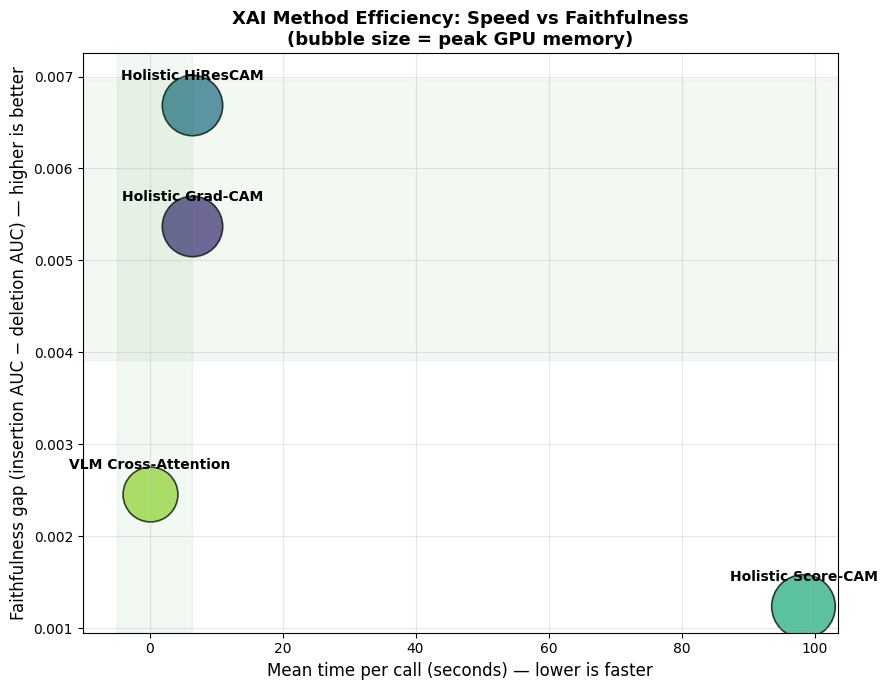

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1115: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'
  [Model Generated]: 'the heart size and mediastinal silhouette are within normal limits for contour the lungs are clear no pneumothorax or pleural effusions the  are intact'


/tmp/ipykernel_1849/1589048449.py:243: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['deletion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))
/tmp/ipykernel_1849/1589048449.py:264: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  results['insertion_auc'] = float(np.trapz(norm, dx=1.0 / n_steps))


Saved: /content/drive/MyDrive/msc_medical_vlm_weights_final/xai_deletion_insertion_curves.png


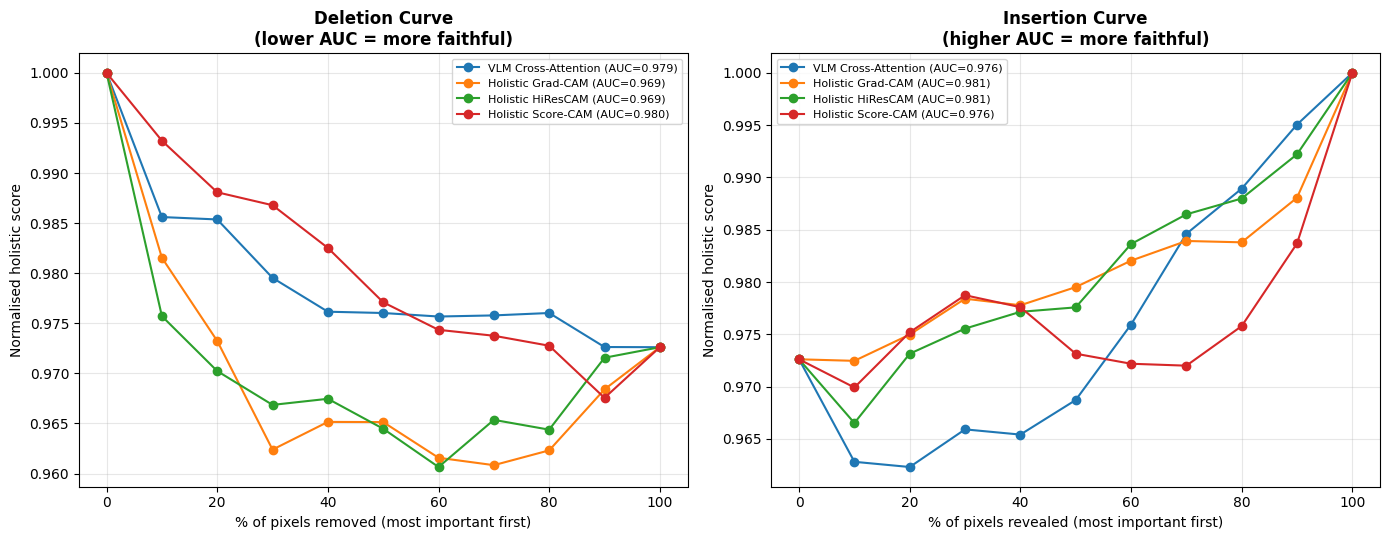

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final"
df.to_csv(f"{SAVE_DIR}/xai_efficiency_raw.csv", index=False)
summary.to_csv(f"{SAVE_DIR}/xai_efficiency_summary.csv", index=False)

plot_efficiency_tradeoff(summary, save_path=f"{SAVE_DIR}/xai_efficiency_tradeoff.png")

# Qualitative deletion/insertion curves for one representative image
sample_image  = test_split[114]['image'].convert('RGB')
sample_prompt = get_random_clinical_prompt()
plot_deletion_insertion_curves(
    sample_image, sample_prompt,
    get_holistic_gradients_and_activations,
    vlm_cross_attention, vlm_gradcam, vlm_hirescam, vlm_scorecam,
    vision_processor, vision_encoder, projector,
    efficient_llm, tokenizer, device,
    n_steps=10, save_path=f"{SAVE_DIR}/xai_deletion_insertion_curves.png"
)